# WC2026 Simulator-Only Question Brier Dashboard

This notebook identifies the exact WC2026 question contracts that the bundled simulator answered, but the main repo's deterministic direct-odds mappers cannot map to API-Football or Odds API specs. It then compares three rules on identical rows for each exact question contract: simulator probability, always 50/50, and always the observed empirical YES rate for that scope.

"Question" here means an exact simulator contract/question template, not a broad family. Literal team/player wordings are aggregated into their exact contract so the same question can be compared on all-history rows and WC2026 rows. The notebook does not call live odds APIs or LLMs.

In [1]:
from __future__ import annotations

import csv
import gc
import gzip
import os
import resource
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import Normalize, TwoSlopeNorm

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "bot").is_dir():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
SIM_SRC = ROOT / "simulator" / "src"
if str(SIM_SRC) not in sys.path:
    sys.path.insert(0, str(SIM_SRC))

from analysis.build_simulator_family_benchmarks import (  # noqa: E402
    DEFAULT_SOURCE_ROOT,
    load_comparison_rows,
)
from bot.matcher import match_intent, match_intent_oddsapi  # noqa: E402
from sphybrid.postsim.catalog import catalog_teams  # noqa: E402

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 9,
})

WC_ROWS_PATH = ROOT / "analysis" / "data" / "simulator_benchmarks" / "exports" / "wc2026_simulator_oos_rows.csv.gz"
CATALOG_PATH = ROOT / "simulator" / "data" / "processed" / "sportspredict_question_catalog.csv"


def peak_rss_mb() -> float:
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024


## Direct-Odds Filter

The filter below uses the main repo's own matcher surface. A contract is direct-mapped when either `bot.matcher.match_intent` or `bot.matcher.match_intent_oddsapi` returns a spec for the exact simulator contract in that match stage. The repo's explicitly labelled proxy specs count as direct mappings here because the production evidence builder treats them as direct evidence.

In [2]:
def _period(value: str) -> str:
    return {"full": "match", "1H": "1H", "2H": "2H"}.get(value, value)


def _time_scope(value: str) -> str:
    return "regulation" if value == "reg" else "full_match"


def _comparator(value: str) -> str:
    return {">=": "gte", ">": "gte", "<=": "lte", "<": "lte"}.get(value, value)


def _threshold(comparator: str, value: str) -> int | float:
    raw = float(value)
    threshold = int(raw) if raw.is_integer() else raw
    if comparator == ">" and raw.is_integer():
        return int(raw) + 1
    if comparator == "<" and raw.is_integer():
        return int(raw) - 1
    return threshold


def _intent(
    market: str,
    subject: str = "match",
    comparator: str = "yes",
    threshold: int | float | None = None,
    period: str = "match",
    *,
    player: str | None = None,
    scope: str = "reg",
) -> dict:
    return {
        "market": market,
        "subject": subject,
        "player": player,
        "comparator": comparator,
        "threshold": threshold,
        "period": period,
        "time_scope": _time_scope(scope),
    }


STAT_MATCH = {
    "goals": "total_goals",
    "corners": "total_corners",
    "cards": "total_cards",
    "offsides": "total_offsides",
    "fouls": "total_fouls",
    "shots_on_target": "total_shots_on_target",
    "shots_total": "total_shots",
}
STAT_TEAM = {
    "goals": "team_total_goals",
    "corners": "team_corners",
    "cards": "team_cards",
    "offsides": "team_offsides",
    "fouls": "team_fouls",
    "shots_on_target": "team_shots_on_target",
    "shots_total": "team_shots",
}
STAT_COMPARE = {
    "goals": "match_winner",
    "corners": "corners_compare",
    "cards": "cards_compare",
    "offsides": "offsides_compare",
    "fouls": "fouls_compare",
    "shots_on_target": "shots_on_target_compare",
}


def intent_candidates_for_contract(key: str) -> list[dict]:
    """Translate an exact simulator contract into matcher intents without LLM calls."""
    parts = key.split(":")
    if parts[0] == "count" and len(parts) >= 7:
        _, stat, scope, half, raw_comp, raw_threshold, raw_scope = parts[:7]
        comparator = _comparator(raw_comp)
        threshold = _threshold(raw_comp, raw_threshold)
        period = _period(half)
        if scope == "match":
            return [_intent(STAT_MATCH.get(stat, "none"), "match", comparator, threshold, period, scope=raw_scope)]
        if scope == "team":
            return [
                _intent(STAT_TEAM.get(stat, "none"), side, comparator, threshold, period, scope=raw_scope)
                for side in ("home", "away")
            ]
        return []

    if parts[0] == "compare" and len(parts) >= 4:
        _, stat, half, raw_scope = parts[:4]
        market = STAT_COMPARE.get(stat, "none")
        comparator = "win" if market == "match_winner" else "more"
        return [
            _intent(market, side, comparator, None, _period(half), scope=raw_scope)
            for side in ("home", "away")
        ]

    if parts[0] == "total_goals" and len(parts) >= 5:
        _, half, raw_comp, raw_threshold, raw_scope = parts[:5]
        return [
            _intent(
                "total_goals",
                "match",
                _comparator(raw_comp),
                _threshold(raw_comp, raw_threshold),
                _period(half),
                scope=raw_scope,
            )
        ]

    fixed = {
        "red_card:match": [_intent("red_card", scope="match")],
        "red_card:reg": [_intent("red_card", scope="reg")],
        "both_teams_card:reg": [_intent("both_teams_card", scope="reg")],
        "penalty_awarded:reg": [_intent("penalty_awarded", scope="reg")],
        "btts:full:reg": [_intent("btts", scope="reg")],
        "match_result:draw:reg": [_intent("match_draw", scope="reg")],
        "half_conditional:halftime_tied": [_intent("match_draw", period="1H", scope="reg")],
        "half_conditional:more_goals_2h": [
            _intent("highest_scoring_half_2h", "match", "second_half_more", scope="reg")
        ],
        "half_conditional:team_goal_in_half": [
            _intent("team_score_2h", side, period="2H", scope="reg") for side in ("home", "away")
        ],
        "card_window:cards:first_half:reg:>=:1": [
            _intent("total_cards", "match", "gte", 1, "1H", scope="reg")
        ],
        "total_shots_threshold:shots_total:>=:20:reg": [
            _intent("total_shots", "match", "gte", 20, scope="reg")
        ],
        "total_shots_threshold:shots_total:>=:22:reg": [
            _intent("total_shots", "match", "gte", 22, scope="reg")
        ],
    }
    if key in fixed:
        return fixed[key]
    if key == "match_result:team:reg":
        return [_intent("match_winner", side, "win", scope="reg") for side in ("home", "away")]
    if key == "match_result:team:advance":
        return [_intent("to_advance", side, scope="match") for side in ("home", "away")]
    if key == "half_conditional:halftime_lead":
        return [_intent("match_winner", side, "win", period="1H", scope="reg") for side in ("home", "away")]
    if key == "first_goal:full:team":
        return [_intent("first_team_to_score", side, scope="match") for side in ("home", "away")]
    if key == "first_goal:2H:team":
        return [_intent("first_team_to_score", side, period="2H", scope="reg") for side in ("home", "away")]
    if key == "win_margin:reg:2":
        return [_intent("win_margin", side, "gte", 2, scope="reg") for side in ("home", "away")]
    if key.startswith("clean_sheet:"):
        return [_intent("team_clean_sheet", side, scope="reg") for side in ("home", "away")]
    if key.startswith("player_stat:shots_on_target:"):
        _, _, half, raw_comp, raw_threshold, raw_scope, _ = parts[:7]
        return [
            _intent(
                "player_shots_on_target",
                "player",
                _comparator(raw_comp),
                _threshold(raw_comp, raw_threshold),
                _period(half),
                player="Player",
                scope=raw_scope,
            )
        ]
    if key.startswith("player_score_or_assist:"):
        _, half, raw_scope, _ = parts[:4]
        return [_intent("player_score_or_assist", "player", player="Player", period=_period(half), scope=raw_scope)]
    if key.startswith("player_score:") or key.startswith("player_goal_scorer:"):
        _, half, raw_scope, _ = parts[:4]
        return [_intent("player_goal_scorer", "player", player="Player", period=_period(half), scope=raw_scope)]
    if key.startswith("player_card:"):
        _, half, raw_scope, _ = parts[:4]
        return [_intent("player_card", "player", player="Player", period=_period(half), scope=raw_scope)]
    return []


def direct_specs_for_contract(key: str, stage: str) -> list[tuple[str, dict]]:
    specs: list[tuple[str, dict]] = []
    for intent in intent_candidates_for_contract(key):
        api_spec = match_intent(intent, "Home", "Away", stage=stage)
        oddsapi_spec = match_intent_oddsapi(intent, "Home", "Away", stage=stage)
        if api_spec:
            specs.append(("api_football", api_spec))
        if oddsapi_spec:
            specs.append(("odds_api", oddsapi_spec))
    return specs


In [3]:
def read_csv(path: Path) -> list[dict[str, str]]:
    if path.suffix == ".gz":
        with gzip.open(path, "rt", newline="") as handle:
            return list(csv.DictReader(handle))
    with path.open(newline="") as handle:
        return list(csv.DictReader(handle))


catalog = pd.DataFrame(read_csv(CATALOG_PATH))
match_meta = catalog[["match_id", "match_name", "kickoff"]].drop_duplicates("match_id").copy()
match_meta[["home", "away"]] = match_meta["match_name"].apply(lambda name: pd.Series(catalog_teams(name)))
match_meta["stage"] = np.where(match_meta["kickoff"].str.slice(0, 10) >= "2026-06-28", "knockout", "group")

wc = pd.DataFrame(read_csv(WC_ROWS_PATH)).merge(
    match_meta[["match_id", "match_name", "kickoff", "home", "away", "stage"]],
    on="match_id",
    how="left",
    suffixes=("", "_catalog"),
)
wc["outcome"] = wc["outcome"].astype(float)
wc["p_model"] = wc["p_model"].astype(float)

spec_records = []
for row in wc.itertuples(index=False):
    specs = direct_specs_for_contract(row.contract_key, row.stage)
    spec_records.append({
        "direct_mapped": bool(specs),
        "direct_sources": ", ".join(sorted({source for source, _ in specs})),
        "direct_spec_count": len(specs),
    })
wc = pd.concat([wc, pd.DataFrame(spec_records)], axis=1)
wc_only = wc.loc[~wc["direct_mapped"]].copy()
selected_contracts = set(wc_only["contract_key"])

del catalog
spec_records.clear()
_ = gc.collect()


In [4]:
STAT_TEXT = {
    "goals": "goals",
    "corners": "corners",
    "cards": "cards",
    "offsides": "offsides",
    "fouls": "fouls",
    "shots_on_target": "shots on target",
    "shots_total": "total shots",
}


def _clean_number(value: str) -> str:
    raw = float(value)
    return str(int(raw)) if raw.is_integer() else str(raw)


def _amount(raw_comp: str, raw_threshold: str) -> str:
    threshold = _clean_number(raw_threshold)
    if raw_comp == ">=":
        return f"{threshold}+"
    if raw_comp == ">":
        return f"> {threshold}"
    if raw_comp == "<=":
        return f"<= {threshold}"
    if raw_comp == "<":
        return f"< {threshold}"
    return f"{raw_comp} {threshold}"


def _period_label(value: str) -> str:
    return {"full": "full", "1H": "1H", "2H": "2H"}.get(value, value)


def _scope_label(value: str) -> str:
    return "regulation" if value == "reg" else "full match incl. ET"


def question_label_from_contract(key: str) -> str:
    parts = key.split(":")
    if parts[0] == "count" and len(parts) >= 7:
        _, stat, scope, half, raw_comp, raw_threshold, raw_scope = parts[:7]
        subject = {"match": "Match", "team": "Team", "each_team": "Each team"}.get(scope, scope)
        return f"{subject}: {_amount(raw_comp, raw_threshold)} {STAT_TEXT.get(stat, stat)} ({_period_label(half)}, {_scope_label(raw_scope)})"
    if parts[0] == "compare" and len(parts) >= 4:
        _, stat, half, raw_scope = parts[:4]
        verb = "commit more" if stat == "fouls" else "more"
        return f"Team {verb} {STAT_TEXT.get(stat, stat)} than opponent ({_period_label(half)}, {_scope_label(raw_scope)})"
    if parts[0] == "total_goals" and len(parts) >= 5:
        _, half, raw_comp, raw_threshold, raw_scope = parts[:5]
        return f"Match: {_amount(raw_comp, raw_threshold)} goals ({_period_label(half)}, {_scope_label(raw_scope)})"
    fixed = {
        "penalty_or_red:reg": "Penalty kick OR red card (regulation)",
        "penalty_or_red:match": "Penalty kick OR red card (full match incl. ET)",
        "btts_and_total:reg": "Both teams score AND 3+ goals (regulation)",
        "compound:first_goal_and_other_team_scores_2h": "Team scores first AND opponent scores in 2H",
        "first_goal:2H:team": "Team scores first goal of 2H",
        "goal_window:before_first_hydration:reg": "Goal before first hydration break",
        "card_window:cards:after_second_hydration:et:>=:1": "Card after second hydration break incl. ET",
        "stat_window:offsides:before_first_hydration:reg:>=:1": "Offside before first hydration break",
        "any_player_threshold:goals:>:1:reg": "Any player scores > 1 goal (regulation)",
        "substitute_score:reg": "Substitute scores a goal (regulation)",
    }
    if key in fixed:
        return fixed[key]
    if key.startswith("player_stat:shots_on_target:"):
        _, _, half, raw_comp, raw_threshold, raw_scope, _ = parts[:7]
        return f"Player: {_amount(raw_comp, raw_threshold)} shots on target ({_period_label(half)}, {_scope_label(raw_scope)})"
    if key.startswith("player_score_or_assist:"):
        _, half, raw_scope, _ = parts[:4]
        return f"Player scores or assists ({_period_label(half)}, {_scope_label(raw_scope)})"
    if key.startswith("player_score:") or key.startswith("player_goal_scorer:"):
        _, half, raw_scope, _ = parts[:4]
        return f"Player scores a goal ({_period_label(half)}, {_scope_label(raw_scope)})"
    return key


label_df = pd.DataFrame({"contract_key": sorted(selected_contracts, key=question_label_from_contract)})
label_df["question"] = label_df["contract_key"].map(question_label_from_contract)
label_df["axis_label"] = label_df.apply(
    lambda row: textwrap.fill(row["question"], width=52) + "\n" + row["contract_key"], axis=1
)


In [5]:
def load_history_rows(contract_keys: set[str]) -> pd.DataFrame:
    rows = load_comparison_rows(DEFAULT_SOURCE_ROOT, contract_keys)
    if not rows:
        return pd.DataFrame(columns=["contract_key", "match_id", "outcome", "p_model"])
    out = pd.DataFrame(rows)
    out = out.loc[out["contract_key"].isin(contract_keys), ["contract_key", "match_id", "outcome", "p_model"]].copy()
    out["outcome"] = out["outcome"].astype(float)
    out["p_model"] = out["p_model"].astype(float)
    return out


def score_scope(rows: pd.DataFrame, scope: str) -> pd.DataFrame:
    if rows.empty:
        return pd.DataFrame(columns=[
            "contract_key", "scope", "observations", "matches", "empirical_rate",
            "simulator", "empirical", "always_50", "simulator_minus_50",
            "simulator_minus_empirical", "empirical_minus_50",
        ])
    work = rows[["contract_key", "match_id", "outcome", "p_model"]].copy()
    work["empirical_rate"] = work.groupby("contract_key")["outcome"].transform("mean")
    work["simulator_loss"] = (work["p_model"] - work["outcome"]) ** 2
    work["empirical_loss"] = (work["empirical_rate"] - work["outcome"]) ** 2
    work["always_50_loss"] = (0.5 - work["outcome"]) ** 2
    summary = work.groupby("contract_key", as_index=False).agg(
        observations=("outcome", "size"),
        matches=("match_id", "nunique"),
        empirical_rate=("empirical_rate", "first"),
        simulator=("simulator_loss", "mean"),
        empirical=("empirical_loss", "mean"),
        always_50=("always_50_loss", "mean"),
    )
    summary["scope"] = scope
    summary["simulator_minus_50"] = summary["simulator"] - summary["always_50"]
    summary["simulator_minus_empirical"] = summary["simulator"] - summary["empirical"]
    summary["empirical_minus_50"] = summary["empirical"] - summary["always_50"]
    return summary


history_rows = load_history_rows(selected_contracts)
wc_scope_rows = wc_only[["contract_key", "match_id", "outcome", "p_model"]].copy()

all_history_summary = score_scope(history_rows, "all_history")
wc2026_summary = score_scope(wc_scope_rows, "wc2026")
summaries = pd.concat([all_history_summary, wc2026_summary], ignore_index=True)
wide = label_df.copy()
for scope, prefix in [("all_history", "history"), ("wc2026", "wc")]:
    scoped = summaries.loc[summaries["scope"] == scope].set_index("contract_key")
    for column in [
        "observations", "matches", "empirical_rate", "simulator", "empirical", "always_50",
        "simulator_minus_50", "simulator_minus_empirical", "empirical_minus_50",
    ]:
        wide[f"{prefix}_{column}"] = wide["contract_key"].map(scoped[column]) if column in scoped else np.nan

wide = wide.sort_values(
    by=["wc_simulator_minus_empirical", "wc_observations", "question"],
    ascending=[True, False, True],
    na_position="last",
).reset_index(drop=True)

summary_line = (
    f"**WC2026 simulator answered:** {len(wc):,} settled question instances across "
    f"{wc['contract_key'].nunique():,} exact question contracts.  "
    f"**Simulator-only after main-repo direct-odds mapping:** {len(wc_only):,} instances, "
    f"{wc_only['question'].nunique():,} literal WC wordings, "
    f"{len(selected_contracts):,} exact question contracts.  "
    f"**All-history rows available for those contracts:** {len(history_rows):,} instances "
    f"across {history_rows['contract_key'].nunique() if not history_rows.empty else 0:,} contracts.  "
    f"Peak RSS after aggregation: {peak_rss_mb():.1f} MB."
)
display(Markdown(summary_line))


**WC2026 simulator answered:** 724 settled question instances across 66 exact question contracts.  **Simulator-only after main-repo direct-odds mapping:** 222 instances, 136 literal WC wordings, 34 exact question contracts.  **All-history rows available for those contracts:** 64,130 instances across 20 contracts.  Peak RSS after aggregation: 450.5 MB.

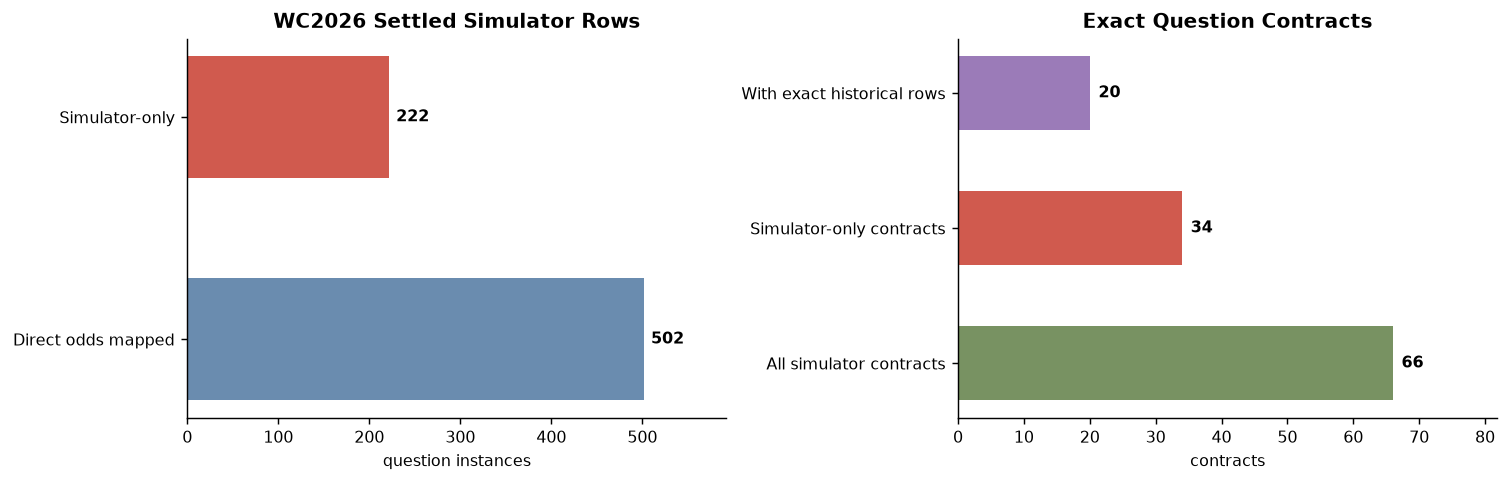

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), constrained_layout=True)

row_counts = pd.Series({
    "Direct odds mapped": int(wc["direct_mapped"].sum()),
    "Simulator-only": int((~wc["direct_mapped"]).sum()),
})
colors = ["#6a8caf", "#d05a4e"]
axes[0].barh(row_counts.index, row_counts.values, color=colors, height=0.55)
for y, value in enumerate(row_counts.values):
    axes[0].text(value + max(row_counts.values) * 0.015, y, f"{value:,}", va="center", fontweight="bold")
axes[0].set_title("WC2026 Settled Simulator Rows")
axes[0].set_xlabel("question instances")
axes[0].set_xlim(0, max(row_counts.values) * 1.18)

contract_counts = pd.Series({
    "All simulator contracts": wc["contract_key"].nunique(),
    "Simulator-only contracts": len(selected_contracts),
    "With exact historical rows": history_rows["contract_key"].nunique() if not history_rows.empty else 0,
})
axes[1].barh(contract_counts.index, contract_counts.values, color=["#789262", "#d05a4e", "#9b7bb8"], height=0.55)
for y, value in enumerate(contract_counts.values):
    axes[1].text(value + max(contract_counts.values) * 0.02, y, f"{value:,}", va="center", fontweight="bold")
axes[1].set_title("Exact Question Contracts")
axes[1].set_xlabel("contracts")
axes[1].set_xlim(0, max(contract_counts.values) * 1.24)

plt.show()


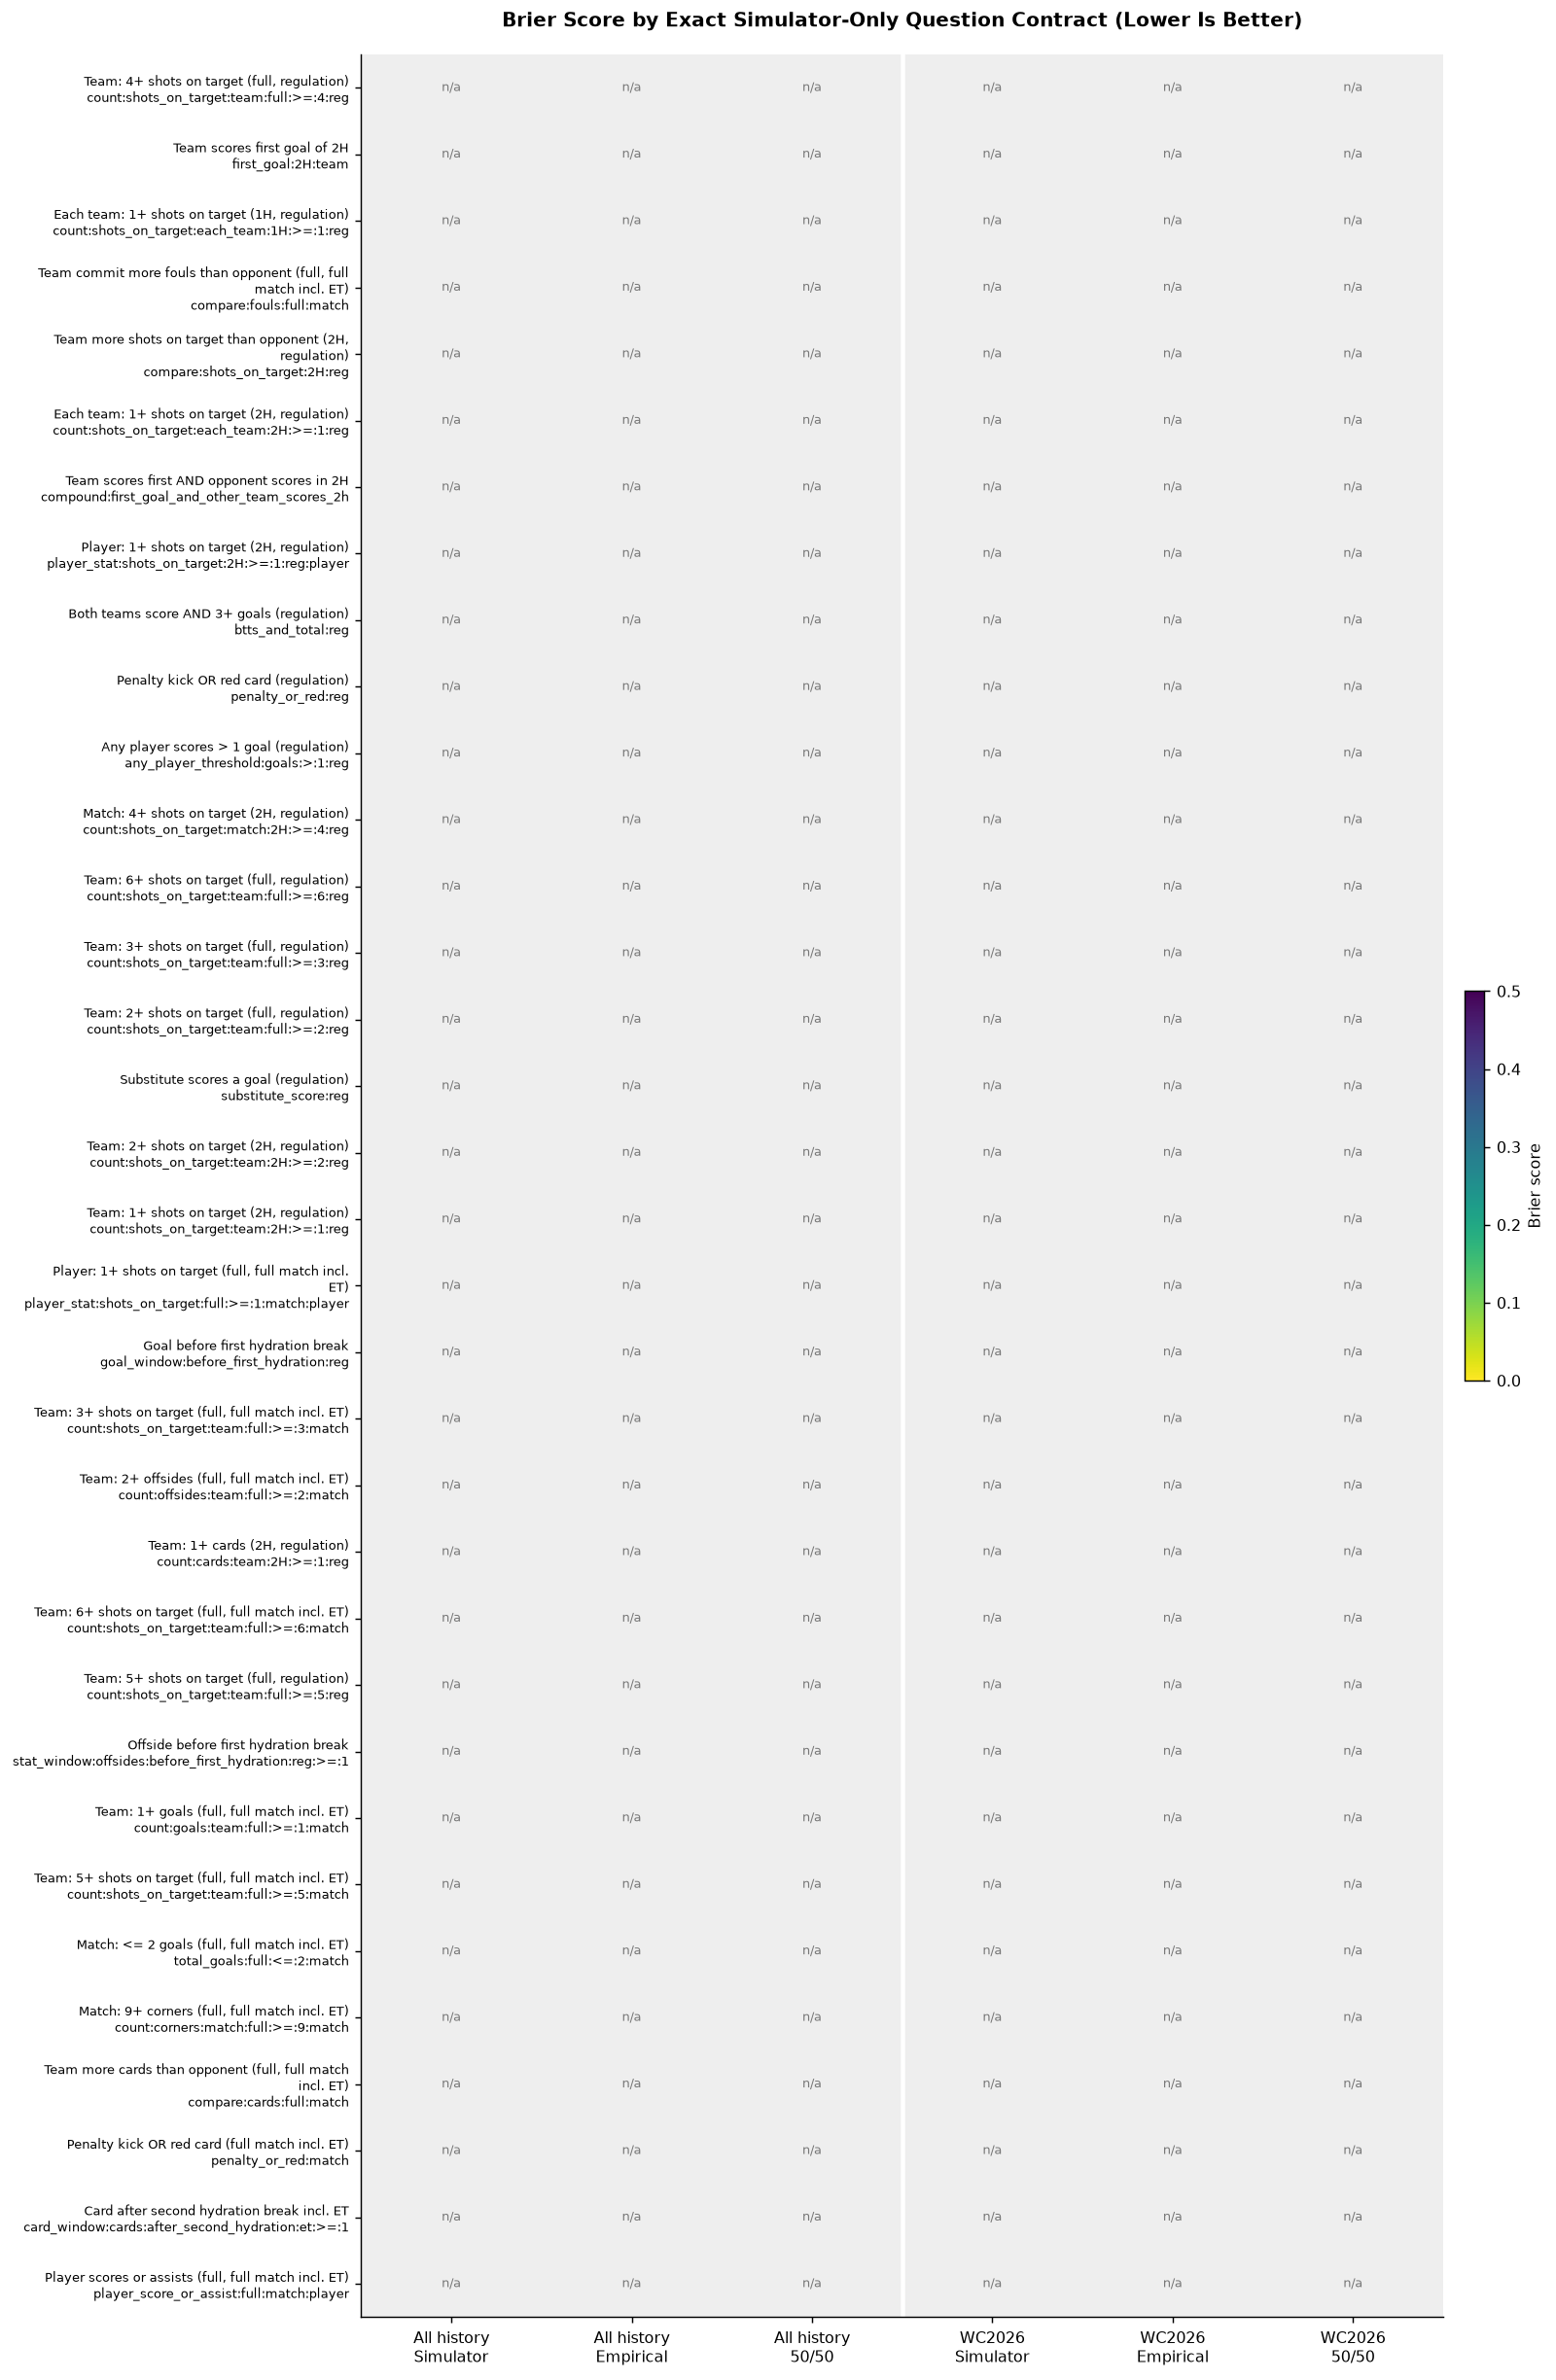

In [7]:
def matrix_from_wide(columns: list[tuple[str, str]]) -> pd.DataFrame:
    return pd.DataFrame({label: wide[source] for label, source in columns}, index=wide["axis_label"])


brier_columns = [
    ("All history\nSimulator", "history_simulator"),
    ("All history\nEmpirical", "history_empirical"),
    ("All history\n50/50", "history_always_50"),
    ("WC2026\nSimulator", "wc_simulator"),
    ("WC2026\nEmpirical", "wc_empirical"),
    ("WC2026\n50/50", "wc_always_50"),
]
brier_matrix = matrix_from_wide(brier_columns)
values = brier_matrix.to_numpy(dtype=float)
valid = values[~np.isnan(values)]
vmax = max(0.32, min(0.75, np.nanpercentile(valid, 95) if len(valid) else 0.5))

fig_height = max(9, 0.48 * len(brier_matrix) + 2.4)
fig, ax = plt.subplots(figsize=(12.2, fig_height), constrained_layout=True)
cmap = plt.get_cmap("viridis_r").copy()
cmap.set_bad("#eeeeee")
image = ax.imshow(np.ma.masked_invalid(values), aspect="auto", cmap=cmap, norm=Normalize(vmin=0, vmax=vmax))
ax.set_xticks(np.arange(len(brier_matrix.columns)))
ax.set_xticklabels(brier_matrix.columns, rotation=0, ha="center")
ax.set_yticks(np.arange(len(brier_matrix.index)))
ax.set_yticklabels(brier_matrix.index)
ax.tick_params(axis="y", labelsize=7.2)
ax.set_title("Brier Score by Exact Simulator-Only Question Contract (Lower Is Better)", pad=16)
ax.axvline(2.5, color="white", linewidth=2.5)

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]
        if np.isnan(value):
            ax.text(j, i, "n/a", ha="center", va="center", color="#777777", fontsize=7)
        else:
            color = "white" if value > vmax * 0.62 else "#222222"
            ax.text(j, i, f"{value:.3f}", ha="center", va="center", color=color, fontsize=7)

cbar = fig.colorbar(image, ax=ax, fraction=0.018, pad=0.02)
cbar.set_label("Brier score")
plt.show()


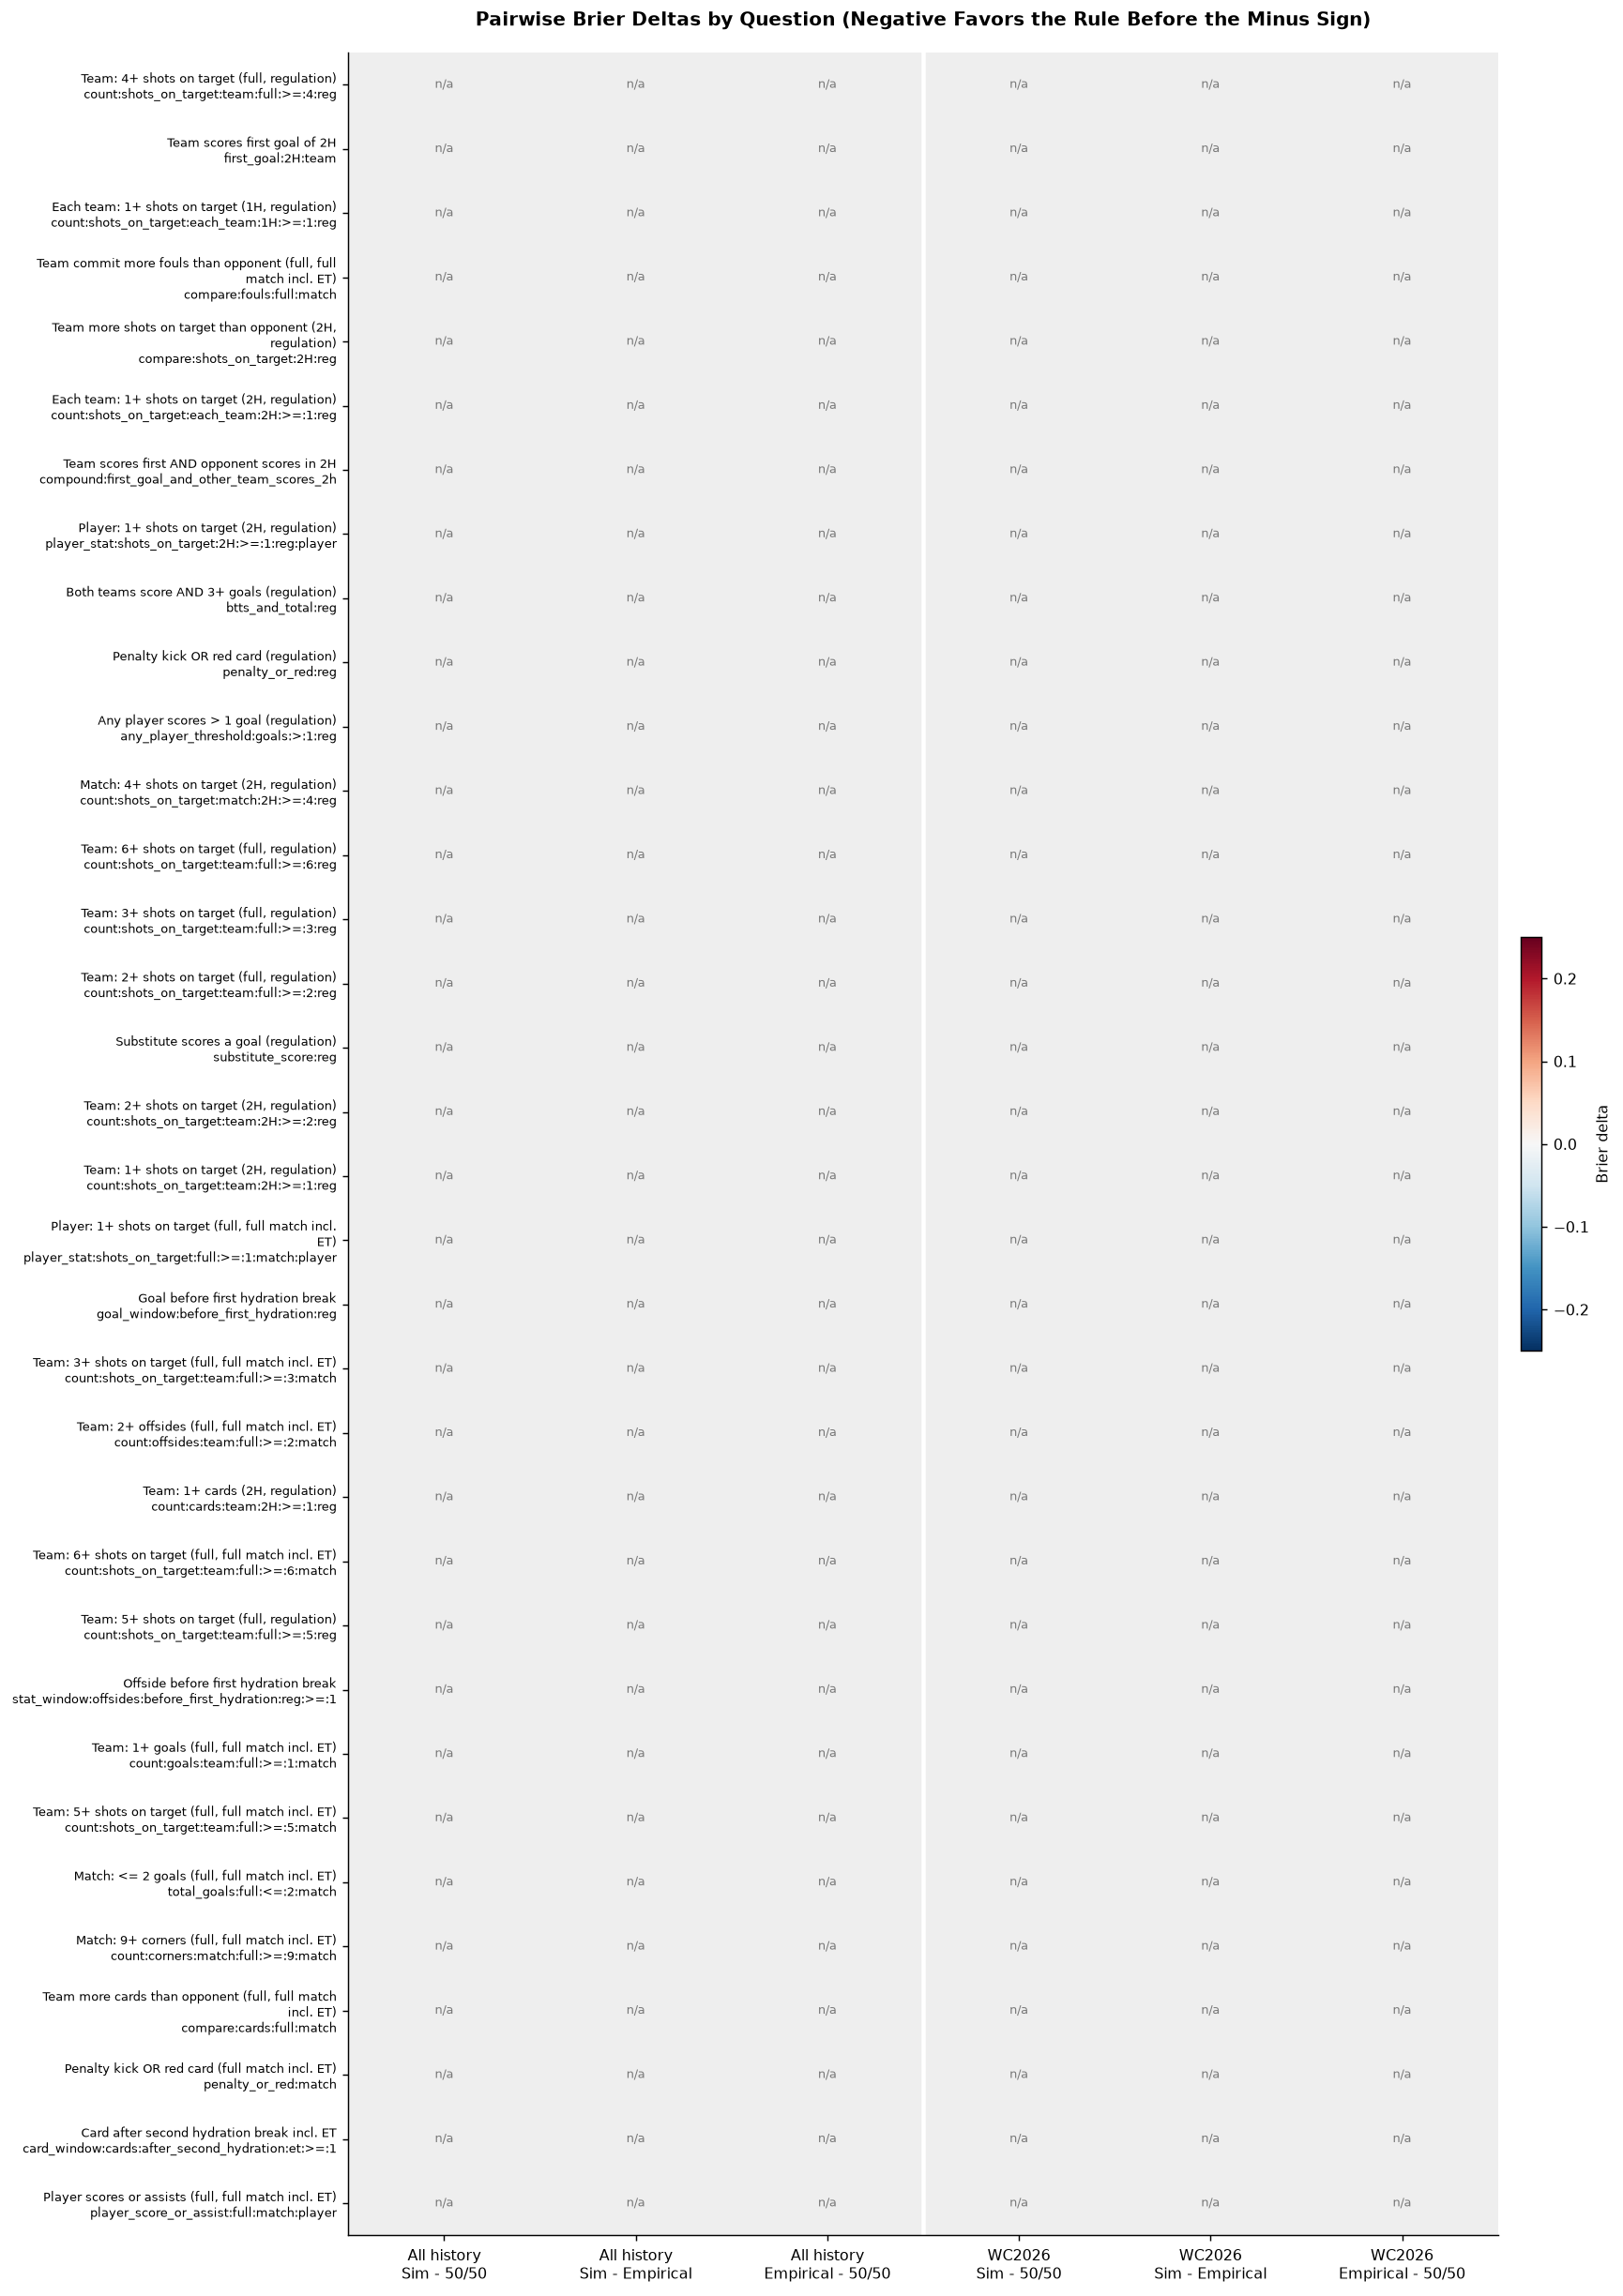

In [8]:
delta_columns = [
    ("All history\nSim - 50/50", "history_simulator_minus_50"),
    ("All history\nSim - Empirical", "history_simulator_minus_empirical"),
    ("All history\nEmpirical - 50/50", "history_empirical_minus_50"),
    ("WC2026\nSim - 50/50", "wc_simulator_minus_50"),
    ("WC2026\nSim - Empirical", "wc_simulator_minus_empirical"),
    ("WC2026\nEmpirical - 50/50", "wc_empirical_minus_50"),
]
delta_matrix = matrix_from_wide(delta_columns)
delta_values = delta_matrix.to_numpy(dtype=float)
valid = delta_values[~np.isnan(delta_values)]
limit = max(0.05, min(0.5, np.nanpercentile(np.abs(valid), 95) if len(valid) else 0.25))

fig_height = max(9, 0.48 * len(delta_matrix) + 2.4)
fig, ax = plt.subplots(figsize=(13.2, fig_height), constrained_layout=True)
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#eeeeee")
image = ax.imshow(
    np.ma.masked_invalid(delta_values),
    aspect="auto",
    cmap=cmap,
    norm=TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit),
)
ax.set_xticks(np.arange(len(delta_matrix.columns)))
ax.set_xticklabels(delta_matrix.columns, rotation=0, ha="center")
ax.set_yticks(np.arange(len(delta_matrix.index)))
ax.set_yticklabels(delta_matrix.index)
ax.tick_params(axis="y", labelsize=7.2)
ax.set_title("Pairwise Brier Deltas by Question (Negative Favors the Rule Before the Minus Sign)", pad=16)
ax.axvline(2.5, color="white", linewidth=2.5)

for i in range(delta_values.shape[0]):
    for j in range(delta_values.shape[1]):
        value = delta_values[i, j]
        if np.isnan(value):
            ax.text(j, i, "n/a", ha="center", va="center", color="#777777", fontsize=7)
        else:
            ax.text(j, i, f"{value:+.3f}", ha="center", va="center", color="#1f1f1f", fontsize=7)

cbar = fig.colorbar(image, ax=ax, fraction=0.018, pad=0.02)
cbar.set_label("Brier delta")
plt.show()


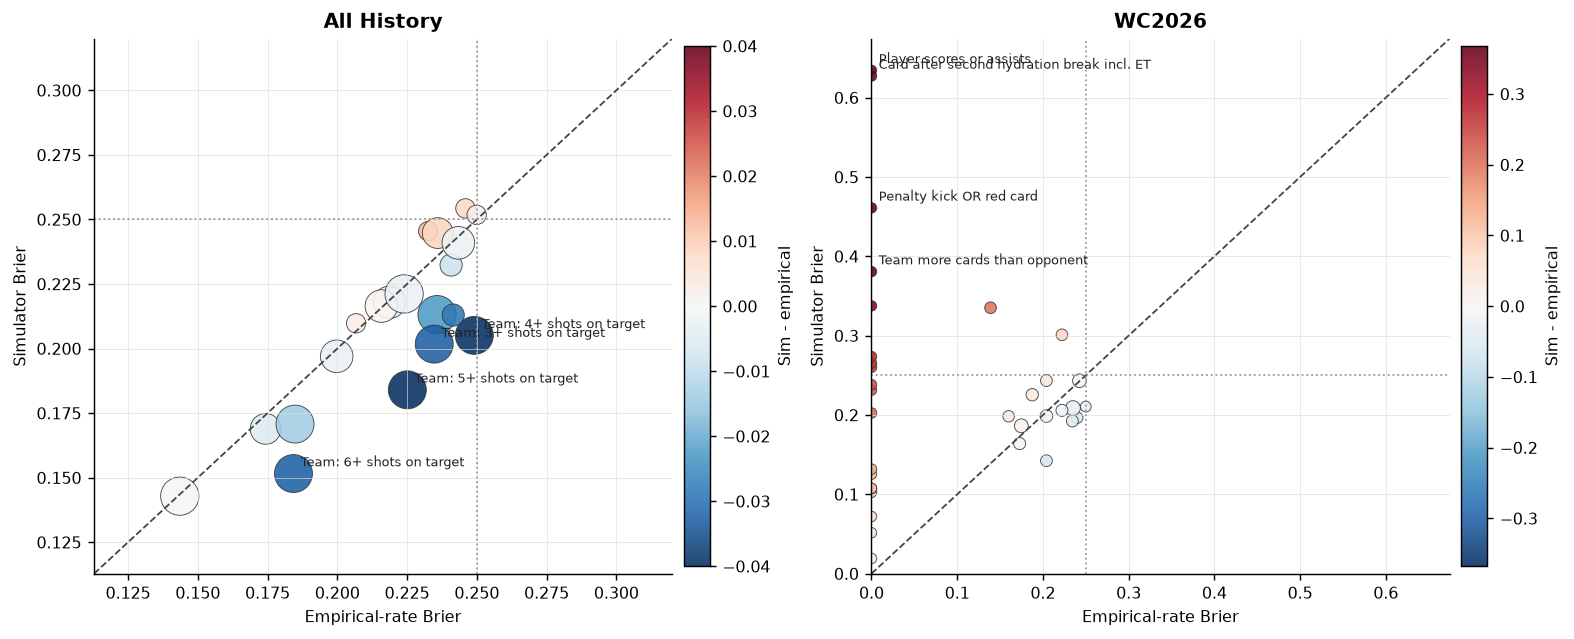

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), constrained_layout=True)
scatter_specs = [
    ("All History", wide.dropna(subset=["history_simulator", "history_empirical"]), "history"),
    ("WC2026", wide.dropna(subset=["wc_simulator", "wc_empirical"]), "wc"),
]

for ax, (title, data, prefix) in zip(axes, scatter_specs, strict=True):
    if data.empty:
        ax.text(0.5, 0.5, "No exact rows", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue
    x = data[f"{prefix}_empirical"].astype(float)
    y = data[f"{prefix}_simulator"].astype(float)
    sizes = 28 + 5.5 * np.sqrt(data[f"{prefix}_observations"].astype(float).fillna(0))
    delta = data[f"{prefix}_simulator_minus_empirical"].astype(float)
    vmax = max(0.04, np.nanpercentile(np.abs(delta), 90))
    sc = ax.scatter(
        x,
        y,
        s=sizes,
        c=delta,
        cmap="RdBu_r",
        norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax),
        edgecolor="#333333",
        linewidth=0.5,
        alpha=0.88,
    )
    lo = max(0, min(x.min(), y.min()) - 0.03)
    hi = min(1, max(x.max(), y.max(), 0.28) + 0.04)
    ax.plot([lo, hi], [lo, hi], color="#444444", linestyle="--", linewidth=1)
    ax.axhline(0.25, color="#999999", linestyle=":", linewidth=1)
    ax.axvline(0.25, color="#999999", linestyle=":", linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(title)
    ax.set_xlabel("Empirical-rate Brier")
    ax.set_ylabel("Simulator Brier")
    ax.grid(True, color="#dddddd", linewidth=0.5, alpha=0.7)
    for _, row in data.reindex(delta.abs().sort_values(ascending=False).index).head(4).iterrows():
        ax.annotate(
            row["question"].split("(")[0].strip(),
            (row[f"{prefix}_empirical"], row[f"{prefix}_simulator"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7,
            color="#222222",
        )
    cbar = fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.02)
    cbar.set_label("Sim - empirical")

plt.show()


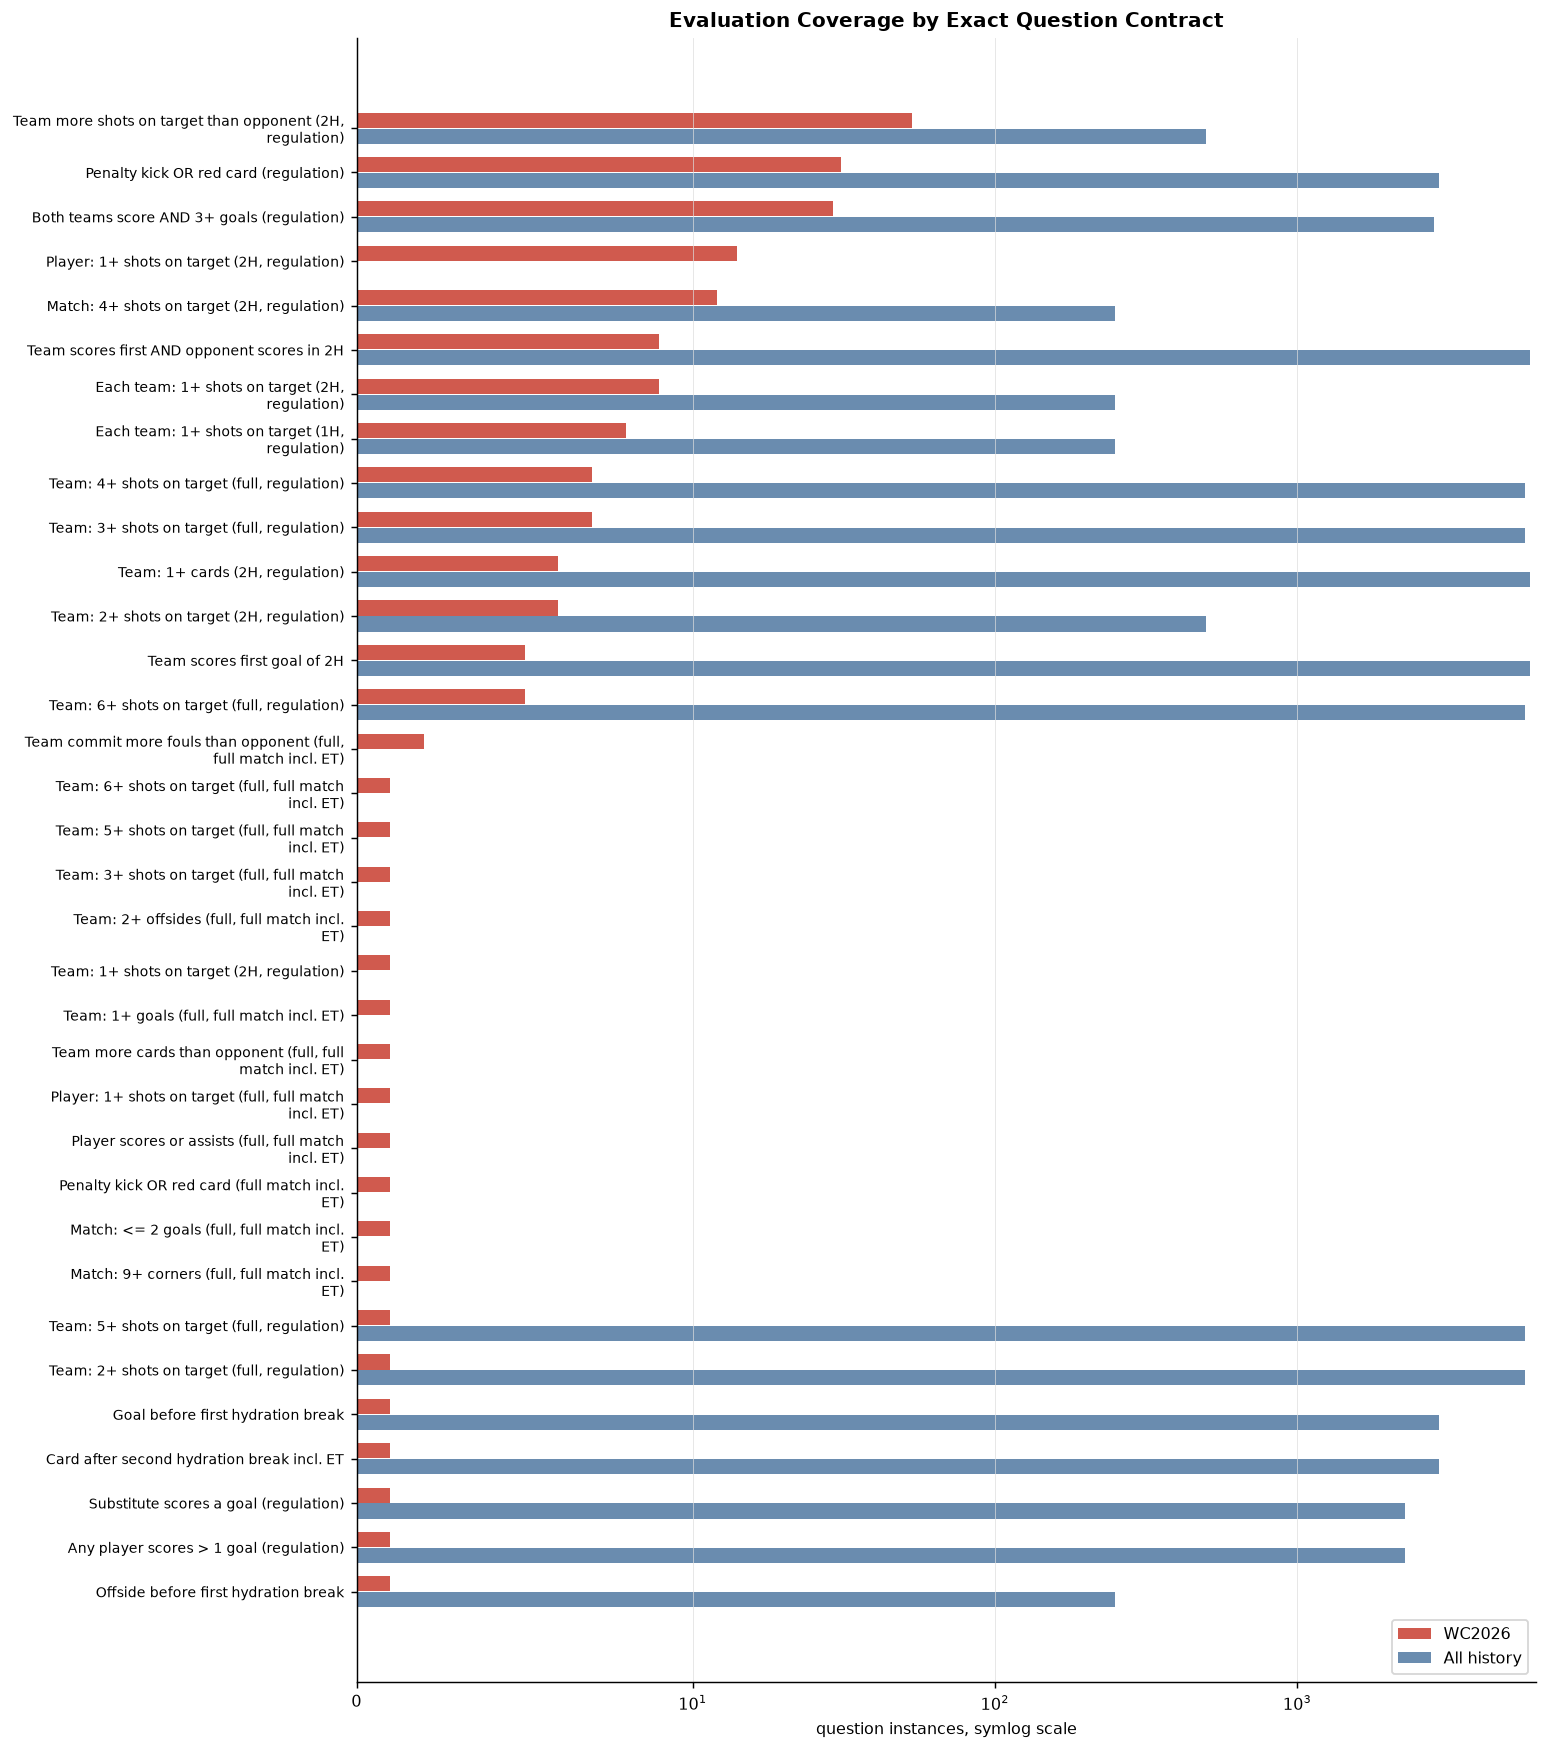

In [10]:
count_plot = wide[["question", "history_observations", "wc_observations"]].copy()
count_plot = count_plot.sort_values(["wc_observations", "history_observations", "question"], ascending=[True, True, True])
labels = [textwrap.fill(label, 44) for label in count_plot["question"]]
y = np.arange(len(count_plot))
fig_height = max(8.5, 0.34 * len(count_plot) + 1.8)
fig, ax = plt.subplots(figsize=(11.8, fig_height), constrained_layout=True)
ax.barh(y + 0.18, count_plot["wc_observations"].fillna(0), height=0.34, color="#d05a4e", label="WC2026")
ax.barh(y - 0.18, count_plot["history_observations"].fillna(0), height=0.34, color="#6a8caf", label="All history")
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=7.5)
ax.set_xscale("symlog", linthresh=10)
ax.set_xlabel("question instances, symlog scale")
ax.set_title("Evaluation Coverage by Exact Question Contract")
ax.legend(loc="lower right")
ax.grid(True, axis="x", color="#dddddd", linewidth=0.5, alpha=0.75)
plt.show()


In [11]:
del history_rows, wc_scope_rows, summaries
collected = gc.collect()
display(Markdown(f"Final cleanup collected `{collected}` objects. Peak RSS: **{peak_rss_mb():.1f} MB**."))


Final cleanup collected `1022` objects. Peak RSS: **450.5 MB**.